# Growth and Treatment Relationships
From the [WGCNA](https://github.com/jgmcdonough/CE24_RNA-seq/tree/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna) analysis, there are some interesting patterns that emerge with gene modules that are significantly correlated with tissue/shell growth and treatments. Here, I want to understand the relationship between growth and treatments to help provide context to the WGCNA results.

## 0. load libraries

In [2]:
library(tidyverse)
library(cowplot) # add plots together
library(grid)
library(plotrix) # for std.error
library(lme4) # for linear mixed effects model

# Phase 2 oysters
The phase 2 oysters only have growth data for phase 2 and not phase 1. 

## 1. load CSVs
reading in the metadata generated from WGCNA - contains the treatment and growth data for the same oysters that were used in the WGCNA analysis

In [3]:
data <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/outputs/p2.wgcna_metadata.csv') %>%
distinct(Sample, .keep_all = TRUE)

dim(data)
head(data)

[1] 92 14

,X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>
1,1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,210.2755,120.72448,0.5741252
2,2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,315.8883,85.61170,0.2710189
3,3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,114.3215,44.47852,0.3890653
4,4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,164.9903,55.10972,0.3340180
5,5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both_both,197.9250,116.17500,0.5869648
6,6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both_control,316.0466,241.35336,0.7636637


#### set levels

In [4]:
# DO
data$Phase1_DO <- factor(data$Phase1_DO, 
                                        levels = c("normoxic", "hypoxic"))
data$Phase2_DO <- factor(data$Phase2_DO, 
                                        levels = c("normoxic", "hypoxic"))

# temp
data$Phase1_temp <- factor(data$Phase1_temp, 
                                        levels = c("ambient", "warm"))
data$Phase2_temp <- factor(data$Phase2_temp, 
                                        levels = c("ambient", "warm"))

# treatment interaction
data$Phase1_treatment <- factor(data$Phase1_treatment,
                                levels = c('control', 'warm', 'hypoxic', 'both'))
data$Phase2_treatment <- factor(data$Phase2_treatment,
                                levels = c('control', 'warm', 'hypoxic', 'both'))

## 2. plot

### Shell Growth

#### A. only looking at Phase 2 treatment

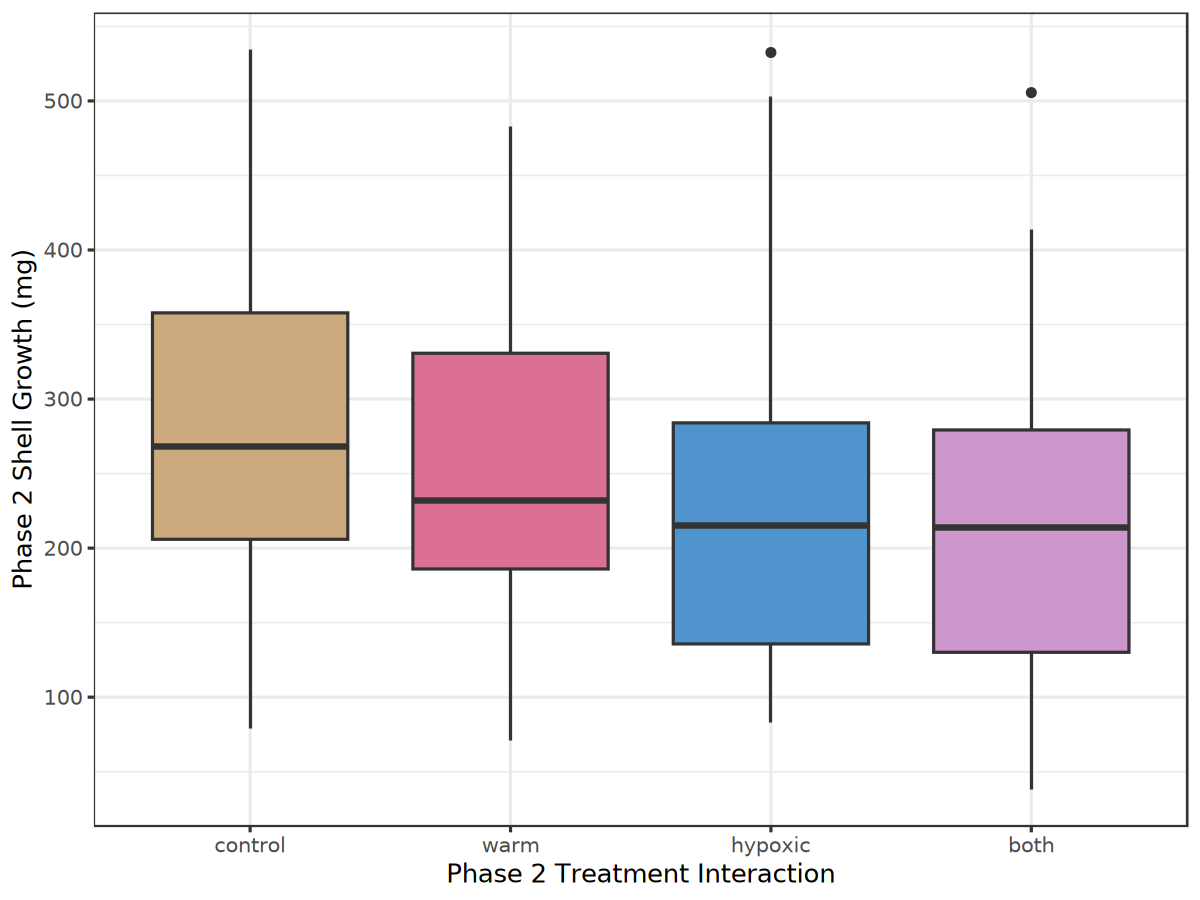

In [5]:
options(repr.plot.height = 7.5, repr.plot.width = 10)

s_phase2 <- ggplot(data, aes(x = Phase2_treatment, y = Actual_shell_growth_mg, fill = Phase2_treatment)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Shell Growth (mg)',
     x = 'Phase 2 Treatment Interaction') +
theme_bw(base_size = 15)

s_phase2

In [6]:
summary(aov(Actual_shell_growth_mg ~ Phase2_treatment, data = data))

                 Df  Sum Sq Mean Sq F value Pr(>F)
Phase2_treatment  3   67626   22542   1.502   0.22
Residuals        88 1320862   15010               

average growth decreases with treatments but not significantly

#### B. Phase 1 and 2 treatment

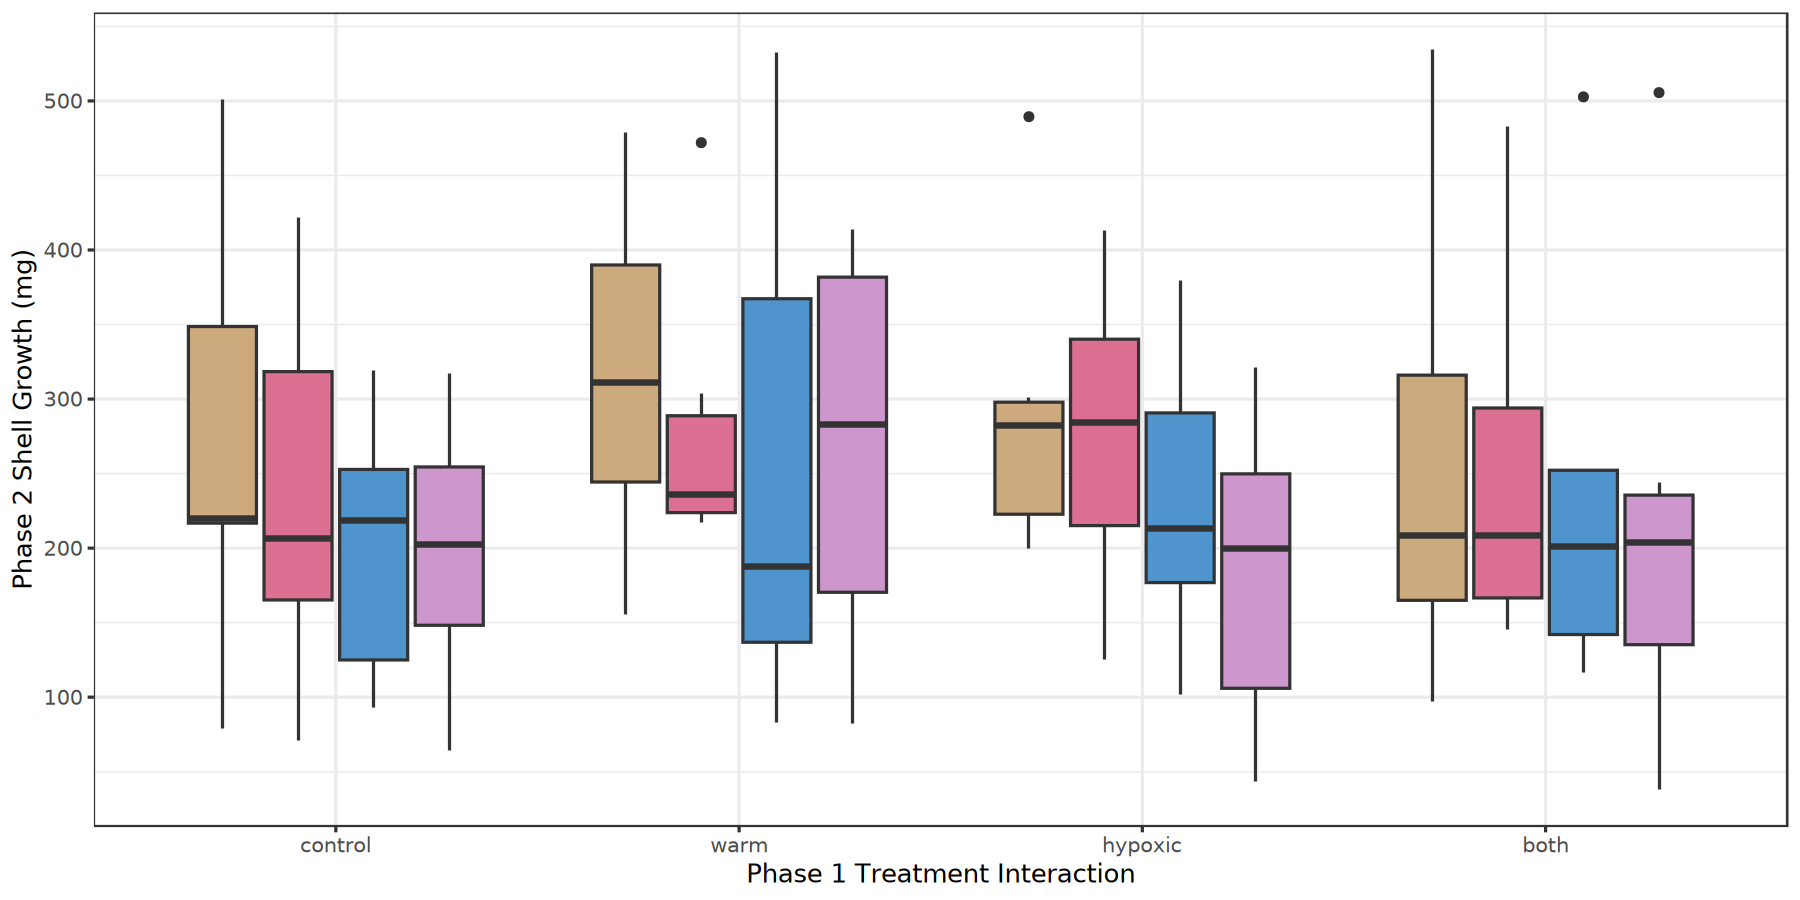

In [7]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

s_all <- ggplot(data, aes(x = Phase1_treatment, y = Actual_shell_growth_mg, fill = Phase2_treatment)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Shell Growth (mg)',
     x = 'Phase 1 Treatment Interaction') +
theme_bw(base_size = 15)

s_all

In [8]:
summary(aov(Actual_shell_growth_mg ~ Phase1_treatment + Phase2_treatment + Phase1_treatment:Phase2_treatment, data = data))

                                  Df  Sum Sq Mean Sq F value Pr(>F)
Phase1_treatment                   3   37503   12501   0.748  0.527
Phase2_treatment                   3   65692   21897   1.310  0.277
Phase1_treatment:Phase2_treatment  9   15340    1704   0.102  1.000
Residuals                         76 1269954   16710               

no significant differences of shell growth between treatments

#### C. Phase 2 temp

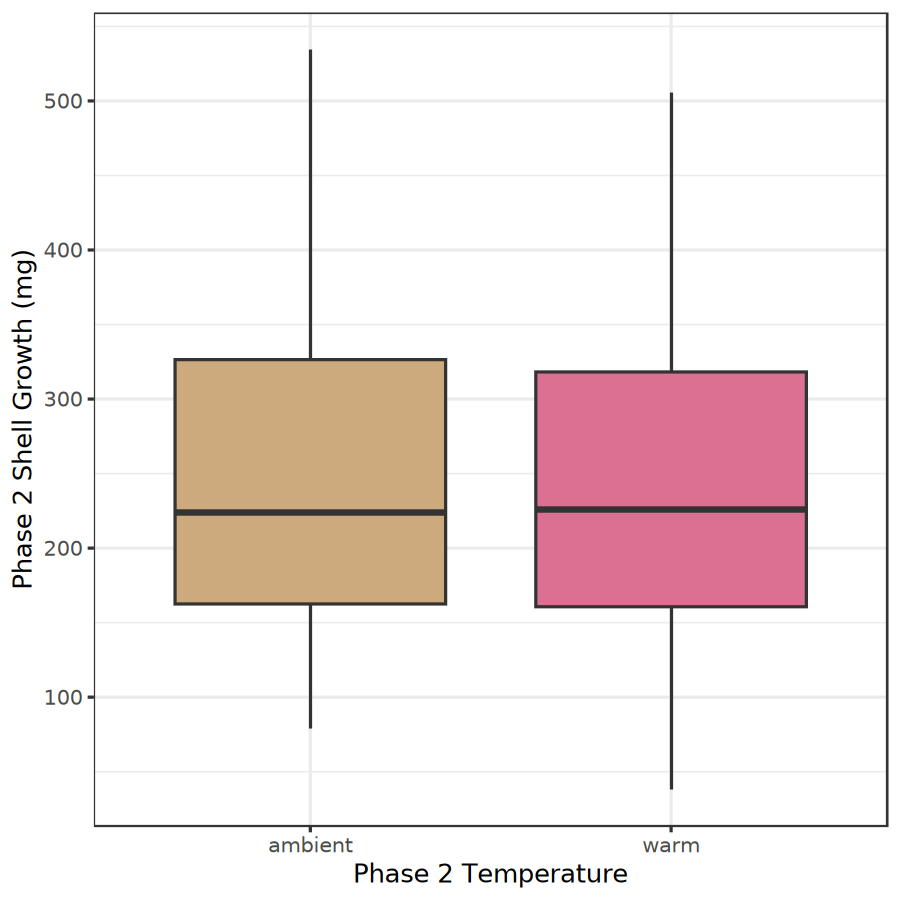

In [9]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

s_p2temp <- ggplot(data, aes(x = Phase2_temp, y = Actual_shell_growth_mg, fill = Phase2_temp)) +
geom_boxplot() +
scale_fill_manual(values = c("warm" = "palevioletred", "ambient" = "burlywood3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Shell Growth (mg)',
     x = 'Phase 2 Temperature') +
theme_bw(base_size = 15)

s_p2temp

In [10]:
summary(aov(Actual_shell_growth_mg ~ Phase2_temp, data = data))

            Df  Sum Sq Mean Sq F value Pr(>F)
Phase2_temp  1   10198   10198   0.666  0.417
Residuals   90 1378290   15314               

no significant differences in shell growth between phase 2 temp treatments

#### D. Phase 2 DO

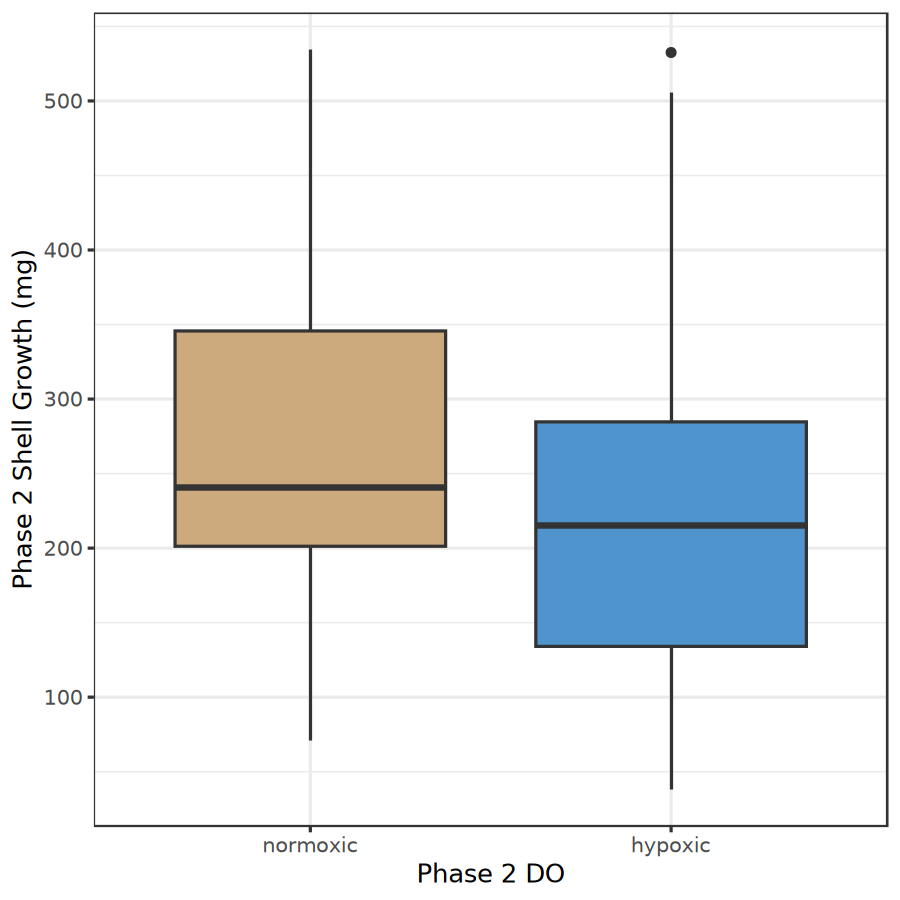

In [11]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

s_p2do <- ggplot(data, aes(x = Phase2_DO, y = Actual_shell_growth_mg, fill = Phase2_DO)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "normoxic" = "burlywood3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Shell Growth (mg)',
     x = 'Phase 2 DO') +
theme_bw(base_size = 15)

s_p2do

In [12]:
summary(aov(Actual_shell_growth_mg ~ Phase2_DO, data = data))

            Df  Sum Sq Mean Sq F value Pr(>F)  
Phase2_DO    1   56737   56737   3.834 0.0533 .
Residuals   90 1331751   14797                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

trending significant (?? lol) difference between shell growth between Phase 2 DO treatments

### Tissue Growth

#### A. only looking at Phase 2 treatment

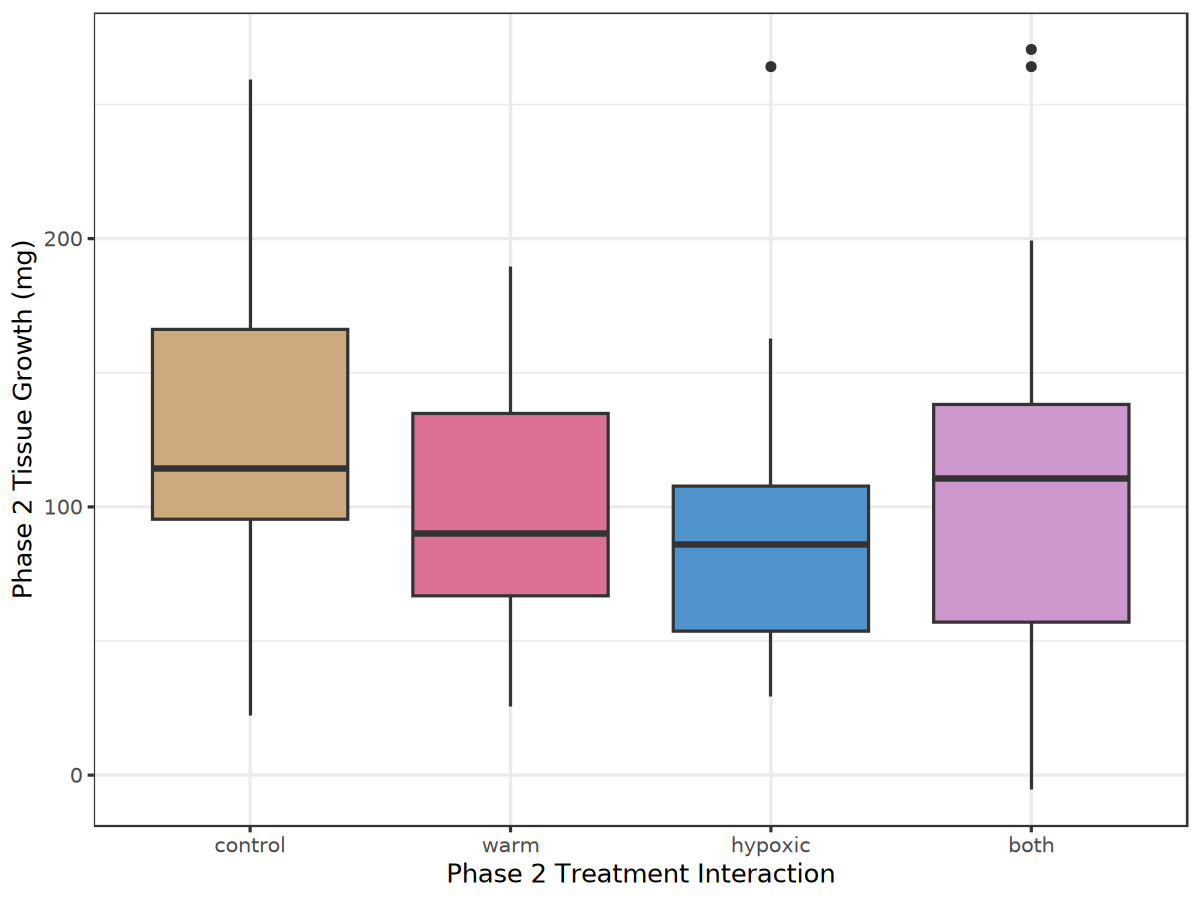

In [13]:
options(repr.plot.height = 7.5, repr.plot.width = 10)

t_phase2 <- ggplot(data, aes(x = Phase2_treatment, y = Actual_tissue_growth_mg, fill = Phase2_treatment)) +
#geom_point(alpha = 0.5) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Tissue Growth (mg)',
     x = 'Phase 2 Treatment Interaction') +
theme_bw(base_size = 15)

t_phase2

In [14]:
summary(aov(Actual_tissue_growth_mg ~ Phase2_treatment, data = data))

                 Df Sum Sq Mean Sq F value Pr(>F)
Phase2_treatment  3  15896    5299   1.524  0.214
Residuals        88 305961    3477               

average growth decreases with treatments but not significantly (and only for single stressors)

#### B. Phase 1 and 2 treatment

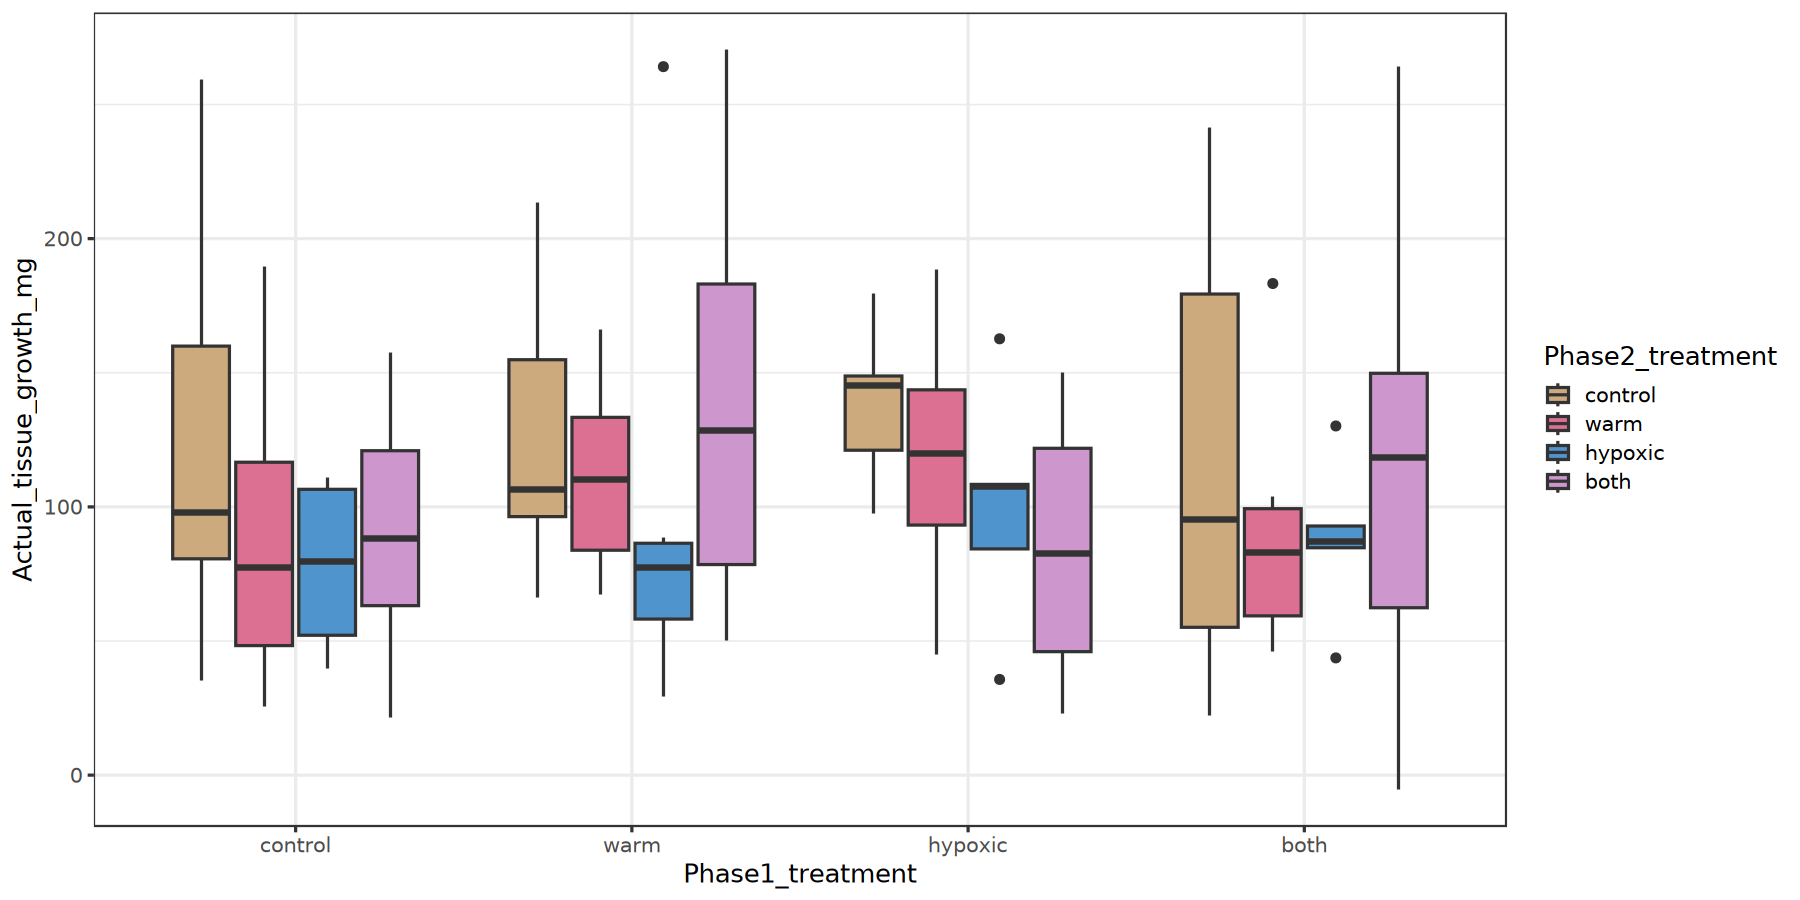

In [15]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

t_all <- ggplot(data, aes(x = Phase1_treatment, y = Actual_tissue_growth_mg, fill = Phase2_treatment)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
theme_bw(base_size = 15)

t_all

In [16]:
summary(aov(Actual_tissue_growth_mg ~ Phase1_treatment + Phase2_treatment + Phase1_treatment:Phase2_treatment, data = data))

                                  Df Sum Sq Mean Sq F value Pr(>F)
Phase1_treatment                   3   7369    2456   0.649  0.586
Phase2_treatment                   3  15284    5095   1.346  0.266
Phase1_treatment:Phase2_treatment  9  11538    1282   0.339  0.959
Residuals                         76 287666    3785               

no significant differences of shell growth between treatments

#### C. Phase 2 temp

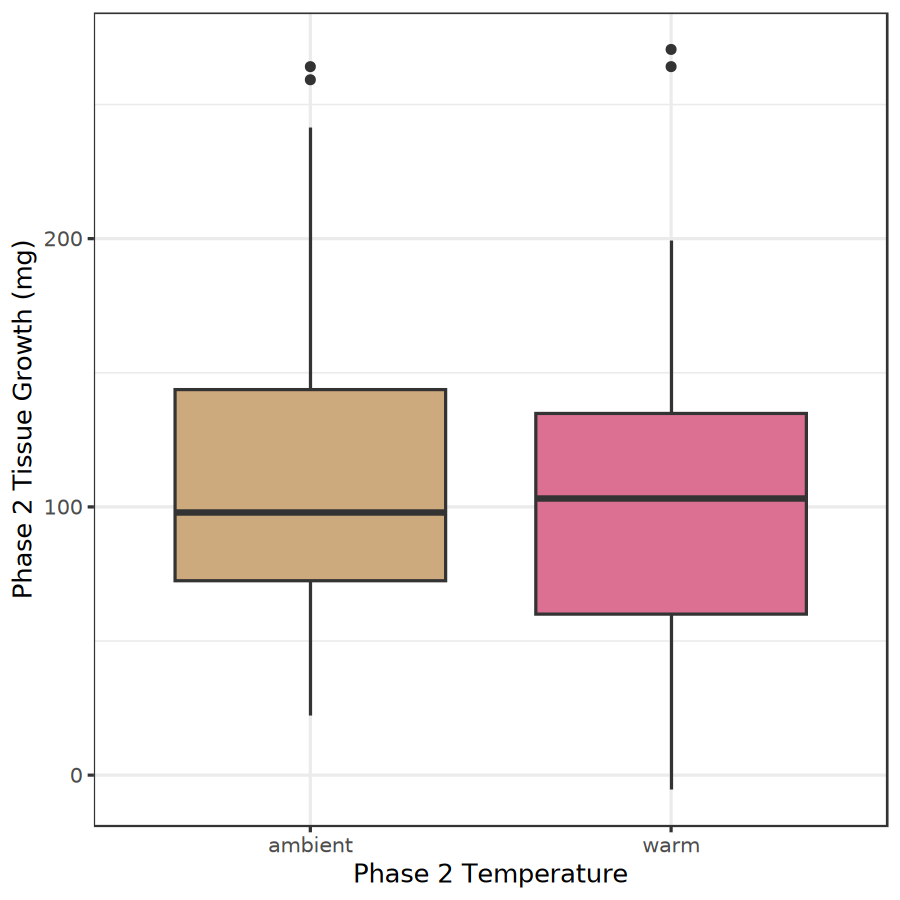

In [17]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

t_p2temp <- ggplot(data, aes(x = Phase2_temp, y = Actual_tissue_growth_mg, fill = Phase2_temp)) +
geom_boxplot() +
scale_fill_manual(values = c("warm" = "palevioletred", "ambient" = "burlywood3")) +
 guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Tissue Growth (mg)',
     x = 'Phase 2 Temperature') +
theme_bw(base_size = 15)

t_p2temp

In [18]:
summary(aov(Actual_tissue_growth_mg ~ Phase2_temp, data = data))

            Df Sum Sq Mean Sq F value Pr(>F)
Phase2_temp  1    350     350   0.098  0.755
Residuals   90 321507    3572               

no significant differences in tissue growth between phase 2 temp treatments

#### D. Phase 2 DO

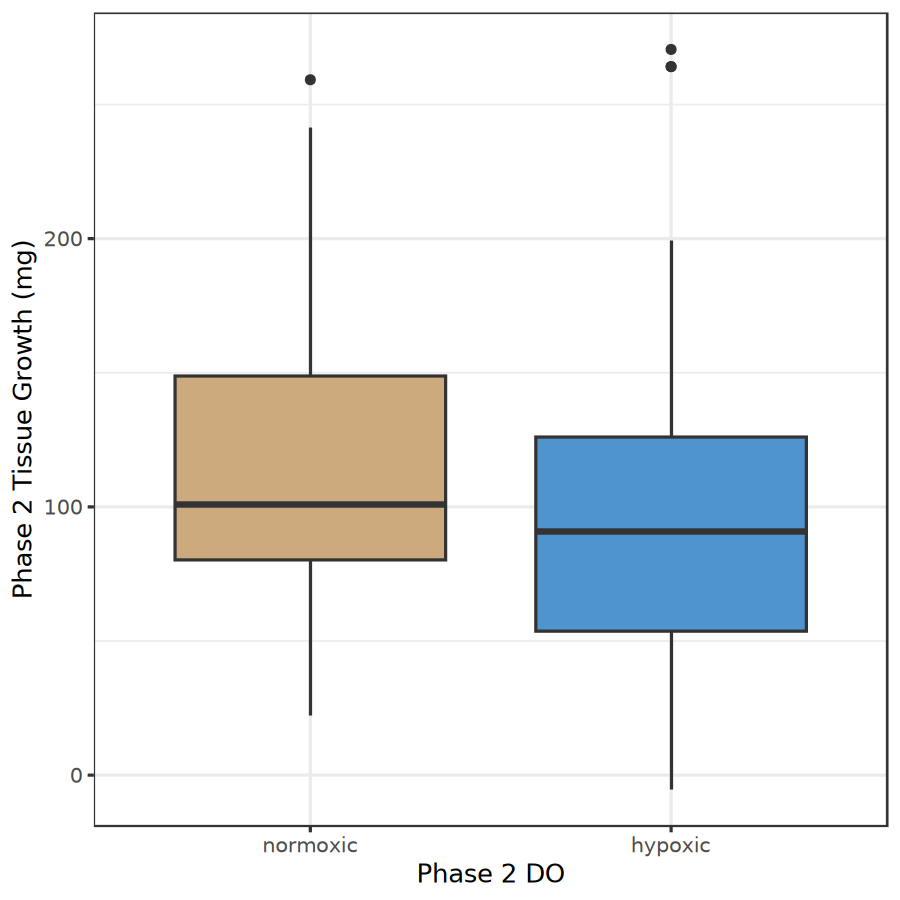

In [19]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

t_p2do <- ggplot(data, aes(x = Phase2_DO, y = Actual_tissue_growth_mg, fill = Phase2_DO)) +
geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "normoxic" = "burlywood3")) +
  guides(fill = "none") + # Remove legend for color
labs(y = 'Phase 2 Tissue Growth (mg)',
     x = 'Phase 2 DO') +
theme_bw(base_size = 15)

t_p2do

In [20]:
summary(aov(Actual_tissue_growth_mg ~ Phase2_DO, data = data))

            Df Sum Sq Mean Sq F value Pr(>F)
Phase2_DO    1   5296    5296   1.506  0.223
Residuals   90 316561    3517               

no significant difference in tissue growth between phase 2 DO treatments

### Add plots together

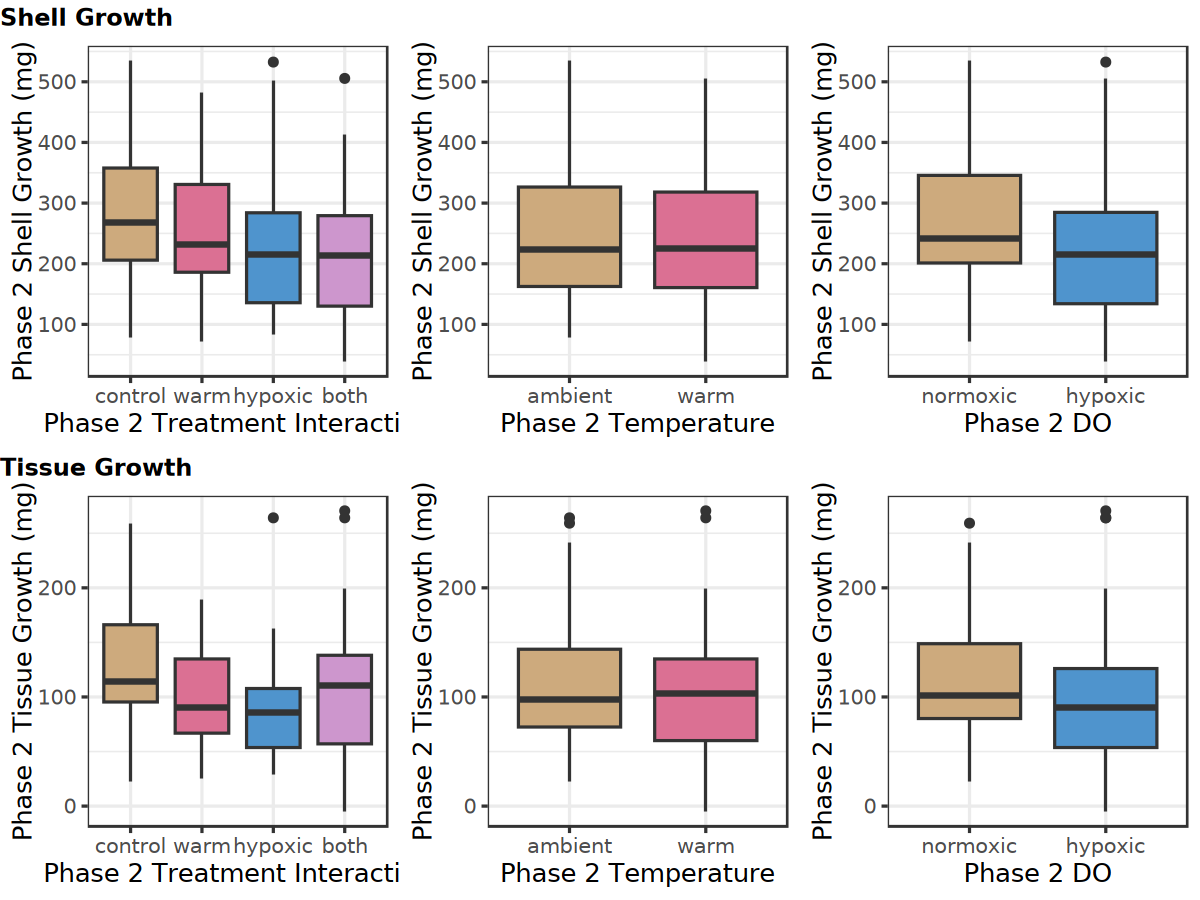

In [21]:
options(repr.plot.height = 7.5, repr.plot.width = 10)

shell_row <- plot_grid(s_phase2, s_p2temp, s_p2do, ncol = 3)
tissue_row <- plot_grid(t_phase2, t_p2temp, t_p2do, ncol = 3)

shell_title <- ggdraw() +
  draw_label("Shell Growth", fontface = "bold", x = 0, hjust = 0)

tissue_title <- ggdraw() +
  draw_label("Tissue Growth", fontface = "bold", x = 0, hjust = 0)

plot_grid(
  shell_title, shell_row,
  tissue_title, tissue_row,
  ncol = 1,
  rel_heights = c(0.08, 1, 0.08, 1)
)

In [22]:
plot_dat <- data %>%
  pivot_longer(
    cols = c(Actual_shell_growth_mg, Actual_tissue_growth_mg),
    names_to = "Response",
    values_to = "Growth"
  )

phase_dat <- plot_dat %>%
  mutate(Predictor = "Phase",
         x = Phase2_treatment)

temp_dat <- plot_dat %>%
  mutate(Predictor = "Temperature",
         x = Phase2_temp)

do_dat <- plot_dat %>%
  mutate(Predictor = "DO",
         x = Phase2_DO)

facet_dat <- bind_rows(phase_dat, temp_dat, do_dat)

# set factor
facet_dat$Predictor <- factor(facet_dat$Predictor,
                              levels = c('Phase','Temperature','DO'))

head(facet_dat)

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Ratio_tissue_shell_mg,Response,Growth,Predictor,x
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_shell_growth_mg,210.27552,Phase,both
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_tissue_growth_mg,120.72448,Phase,both
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_shell_growth_mg,315.88830,Phase,warm
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_tissue_growth_mg,85.61170,Phase,warm
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,0.3890653,Actual_shell_growth_mg,114.32148,Phase,both
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,0.3890653,Actual_tissue_growth_mg,44.47852,Phase,both


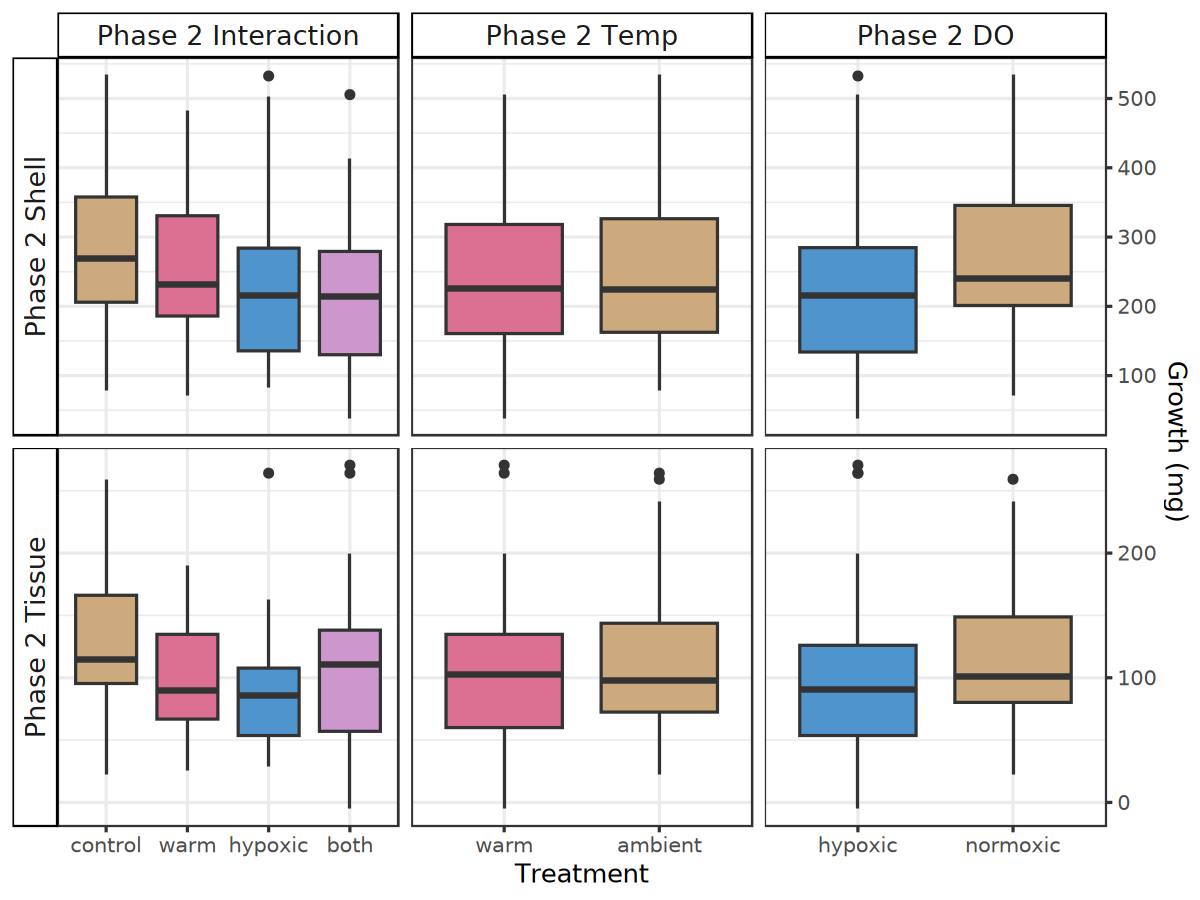

In [23]:
ggplot(facet_dat, aes(x = x, y = Growth, fill = x)) +
geom_boxplot() +
facet_grid(Response ~ Predictor, scales = 'free',
          switch = 'y',
           labeller = labeller(
      Response = c(
        "Actual_shell_growth_mg" = "Phase 2 Shell",
        "Actual_tissue_growth_mg" = "Phase 2 Tissue"
      ),
      Predictor = c(
        "Phase" = "Phase 2 Interaction",
        "Temperature" = "Phase 2 Temp",
        "DO" = "Phase 2 DO"
      ))) +
scale_y_continuous(position = "right") +   # move y-axis to right 
scale_fill_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3", "ambient" = "burlywood3", "normoxic" = "burlywood3")) +
guides(fill = 'none') +
labs(x = 'Treatment',
    y = 'Growth (mg)') +
theme_bw(base_size = 15) +
theme(
  strip.background = element_rect(
    fill = "white",
    colour = "black"   # optional border
  ),
  strip.text = element_text(size = 16)
) 

In [24]:
head(facet_dat)

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Ratio_tissue_shell_mg,Response,Growth,Predictor,x
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_shell_growth_mg,210.27552,Phase,both
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_tissue_growth_mg,120.72448,Phase,both
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_shell_growth_mg,315.88830,Phase,warm
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_tissue_growth_mg,85.61170,Phase,warm
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,0.3890653,Actual_shell_growth_mg,114.32148,Phase,both
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,0.3890653,Actual_tissue_growth_mg,44.47852,Phase,both


In [25]:
summary_stats <- facet_dat %>%
  group_by(Predictor, x, Response) %>%
  mutate(
    mean_growth = mean(Growth, na.rm = TRUE),
    se_growth = std.error(Growth, na.rm = TRUE)) %>%
distinct(Response, Predictor, x, .keep_all = TRUE)

summary_stats

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Ratio_tissue_shell_mg,Response,Growth,Predictor,x,mean_growth,se_growth
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_shell_growth_mg,210.27552,Phase,both,217.19630,24.853705
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_tissue_growth_mg,120.72448,Phase,both,107.90787,14.432378
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_shell_growth_mg,315.88830,Phase,warm,261.61726,22.376292
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_tissue_growth_mg,85.61170,Phase,warm,102.87023,9.866750
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,0.3340180,Actual_shell_growth_mg,164.99028,Phase,control,288.17880,27.611754
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,0.3340180,Actual_tissue_growth_mg,55.10972,Phase,control,127.90756,13.377417
8,B3_H4_O41,both,warm,hypoxic,3,hypoxic,ambient,hypoxic,4,both_hypoxic,0.6123243,Actual_shell_growth_mg,142.03098,Phase,hypoxic,232.78859,27.573975
8,B3_H4_O41,both,warm,hypoxic,3,hypoxic,ambient,hypoxic,4,both_hypoxic,0.6123243,Actual_tissue_growth_mg,86.96902,Phase,hypoxic,90.68414,10.867852
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_shell_growth_mg,210.27552,Temperature,warm,239.40678,16.856695


In [26]:
# set factor levels
summary_stats$x <- factor(summary_stats$x,
                          levels = c('control', 'ambient', 'normoxic', 'warm', 'hypoxic', 'both'))

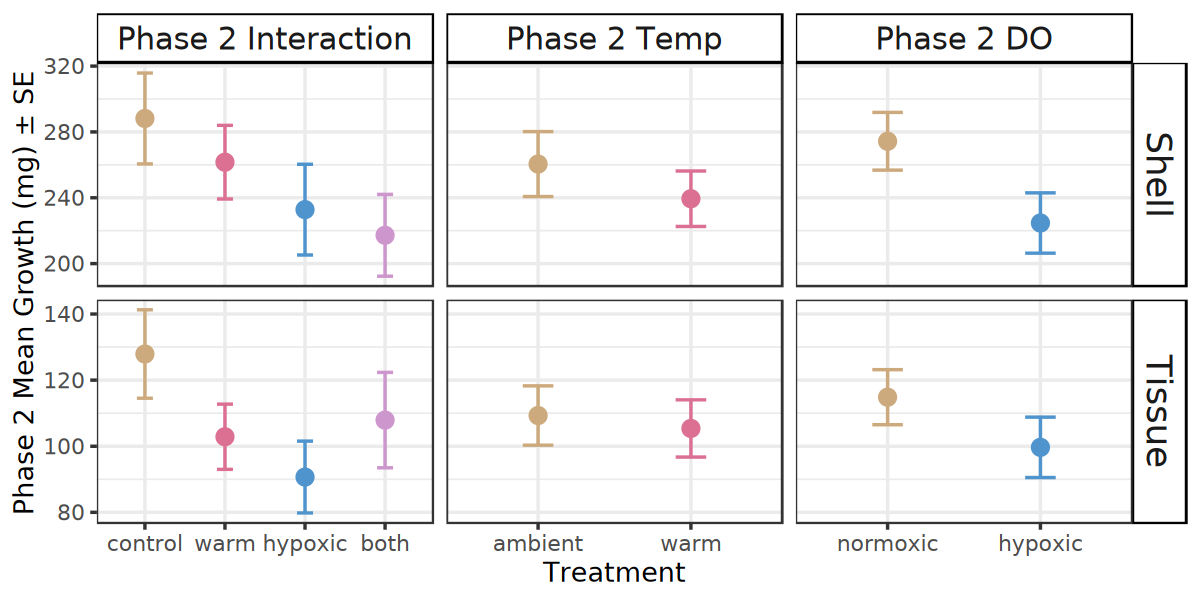

In [27]:
options(repr.plot.width = 10, repr.plot.height = 5)

p <- ggplot(summary_stats, aes(x = x, y = mean_growth, color = x)) +
# Plot means as points
geom_point(size = 4, position = position_dodge(0.9)) + 
 # Error bars for SD
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
# facet grid
facet_grid(Response ~ Predictor, scales = 'free',
           labeller = labeller(
      Response = c(
        "Actual_shell_growth_mg" = "Shell",
        "Actual_tissue_growth_mg" = "Tissue"
      ),
      Predictor = c(
        "Phase" = "Phase 2 Interaction",
        "Temperature" = "Phase 2 Temp",
        "DO" = "Phase 2 DO"
      ))) +
#scale_y_continuous(position = "right") +   # move y-axis to right 
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3", "ambient" = "burlywood3", "normoxic" = "burlywood3")) +
guides(fill = 'none') +
labs(x = 'Treatment',
    y = 'Phase 2 Mean Growth (mg) ± SE') +
theme_bw(base_size = 16) +
theme(
  strip.background = element_rect(
    fill = "white",
    colour = "black"   # optional border
  ),
  strip.text = element_text(size = 21),
     strip.text.x = element_text(size = 18),      # column labels only
    legend.position = "none"
) 

p

In [28]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/plots/growth_treatment.png', 
  plot = p, 
  width = 10,    
  height = 5,     
  units = "in", 
  dpi = 300         # High resolution for clarity
)

In [29]:
summary_stats %>%
filter(

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Ratio_tissue_shell_mg,Response,Growth,Predictor,x,mean_growth,se_growth
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_shell_growth_mg,210.27552,Phase,both,217.1963,24.85371
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_tissue_growth_mg,120.72448,Phase,both,107.9079,14.43238
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_shell_growth_mg,315.88830,Phase,warm,261.6173,22.37629
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_tissue_growth_mg,85.61170,Phase,warm,102.8702,9.86675
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,0.3340180,Actual_shell_growth_mg,164.99028,Phase,control,288.1788,27.61175
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,0.3340180,Actual_tissue_growth_mg,55.10972,Phase,control,127.9076,13.37742


### Isolate phase 2 interaction plots

In [37]:
phase2_inter <- summary_stats %>%
filter(Predictor == 'Phase')
phase2_inter

# separate into two groups
p2_shell <- phase2_inter %>% filter(Response == 'Actual_shell_growth_mg')
p2_tissue <- phase2_inter %>% filter(Response == 'Actual_tissue_growth_mg')

X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Ratio_tissue_shell_mg,Response,Growth,Predictor,x,mean_growth,se_growth
<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_shell_growth_mg,210.27552,Phase,both,217.19630,24.85371
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,0.5741252,Actual_tissue_growth_mg,120.72448,Phase,both,107.90787,14.43238
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_shell_growth_mg,315.88830,Phase,warm,261.61726,22.37629
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,0.2710189,Actual_tissue_growth_mg,85.61170,Phase,warm,102.87023,9.86675
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,0.3340180,Actual_shell_growth_mg,164.99028,Phase,control,288.17880,27.61175
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,0.3340180,Actual_tissue_growth_mg,55.10972,Phase,control,127.90756,13.37742
8,B3_H4_O41,both,warm,hypoxic,3,hypoxic,ambient,hypoxic,4,both_hypoxic,0.6123243,Actual_shell_growth_mg,142.03098,Phase,hypoxic,232.78859,27.57397
8,B3_H4_O41,both,warm,hypoxic,3,hypoxic,ambient,hypoxic,4,both_hypoxic,0.6123243,Actual_tissue_growth_mg,86.96902,Phase,hypoxic,90.68414,10.86785


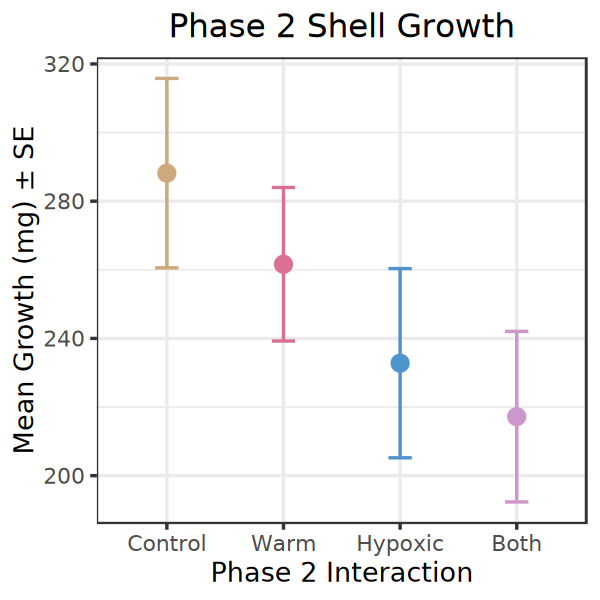

In [66]:
options(repr.plot.width = 5, repr.plot.height = 5)

shell <- ggplot(p2_shell, aes(x = x, y = mean_growth, color = x)) +
# Plot means as points
geom_point(size = 4, position = position_dodge(0.9)) + 
 # Error bars for SD
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
#scale_y_continuous(position = "right") +   # move y-axis to right 
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
scale_x_discrete(labels = stringr::str_to_title) +
guides(fill = 'none') +
labs(x = 'Phase 2 Interaction',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 2 Shell Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

shell

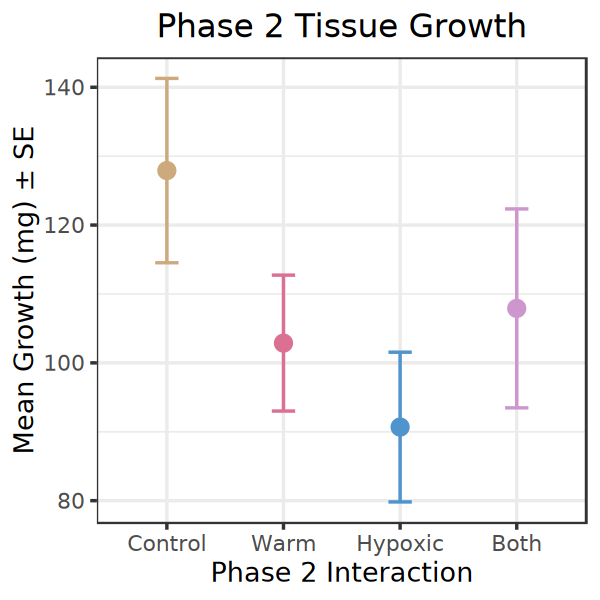

In [67]:
options(repr.plot.width = 5, repr.plot.height = 5)

tissue <- ggplot(p2_tissue, aes(x = x, y = mean_growth, color = x)) +
# Plot means as points
geom_point(size = 4, position = position_dodge(0.9)) + 
 # Error bars for SD
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
#scale_y_continuous(position = "right") +   # move y-axis to right 
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
scale_x_discrete(labels = stringr::str_to_title) +
guides(fill = 'none') +
labs(x = 'Phase 2 Interaction',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 2 Tissue Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

tissue

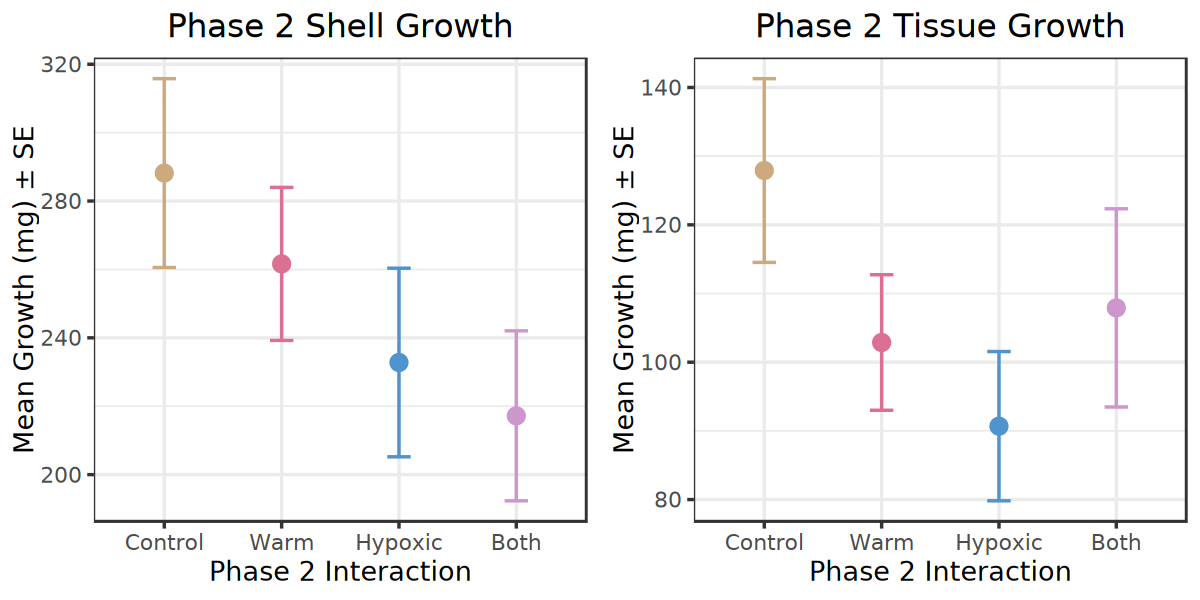

In [68]:
options(repr.plot.height = 5, repr.plot.width = 10)

plot1 <- plot_grid(shell, tissue)
plot1

In [69]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/plots/phase2_growth.png', 
  plot = plot1, 
  width = 10,    
  height = 5,     
  units = "in", 
  dpi = 300         # High resolution for clarity
)

### Stat testing

In [49]:
head(data)

,X,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<int>,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<dbl>,<dbl>
1,1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,210.2755,120.72448,0.5741252
2,2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,315.8883,85.61170,0.2710189
3,3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,114.3215,44.47852,0.3890653
4,4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,164.9903,55.10972,0.3340180
5,5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both_both,197.9250,116.17500,0.5869648
6,6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both_control,316.0466,241.35336,0.7636637


In [56]:
m1 <- aov(Actual_tissue_growth_mg ~ Phase1_DO*Phase1_temp*Phase2_temp*Phase2_DO, data = data)
summary(m1)

                                            Df Sum Sq Mean Sq F value Pr(>F)
Phase1_DO                                    1      0       0   0.000  0.994
Phase1_temp                                  1   1835    1835   0.485  0.488
Phase2_temp                                  1    352     352   0.093  0.761
Phase2_DO                                    1   5293    5293   1.398  0.241
Phase1_DO:Phase1_temp                        1   5245    5245   1.386  0.243
Phase1_DO:Phase2_temp                        1    681     681   0.180  0.673
Phase1_temp:Phase2_temp                      1   2849    2849   0.753  0.388
Phase1_DO:Phase2_DO                          1    340     340   0.090  0.765
Phase1_temp:Phase2_DO                        1   4842    4842   1.279  0.262
Phase2_temp:Phase2_DO                        1   9920    9920   2.621  0.110
Phase1_DO:Phase1_temp:Phase2_temp            1     89      89   0.024  0.878
Phase1_DO:Phase1_temp:Phase2_DO              1    161     161   0.043  0.837

# Phase 1 oysters

## 1. load CSVs

In [18]:
p1.growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase1_weights.csv')
head(p1.growth)

,Sample_Name,Order_pre,Date_MMDDYYYY_pre,Year,Phase_1_treat,Phase_1_rep,Phase_2_treat,Phase_2_rep,Tag_color,Tag_num,⋯,Notes_post,Actual_shell_pre_mg,Actual_shell_post_mg,Actual_shell_growth_mg,Actual_tissue_pre_mg,Actual_tissue_post_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,Phase_1_temp,Phase_1_DO
,<chr>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,2024_Both01_Null_O1,98,5312024,2024,Both,1,null,null,O,1,⋯,NA,30.76476,73.04154,42.27678,24.33524,46.25846,21.92322,0.518564091,Warm,Hyp
2,2024_Both01_Null_O2,99,5312024,2024,Both,1,null,null,O,2,⋯,NA,41.05686,104.70954,63.65268,33.24314,75.59046,42.34732,0.665287306,Warm,Hyp
3,2024_Both01_Null_O3,100,5312024,2024,Both,1,null,null,O,3,⋯,NA,39.94848,117.53508,77.58660,33.05152,60.96492,27.91340,0.359770888,Warm,Hyp
4,2024_Both01_Null_O4,101,5312024,2024,Both,1,null,null,O,4,⋯,NA,66.39126,223.78122,157.38996,66.90874,215.11878,148.21004,0.941674043,Warm,Hyp
5,2024_Both01_Null_O5,102,5312024,2024,Both,1,null,null,O,5,⋯,NA,28.70634,9.23052,-19.47582,43.59366,3.56948,-40.02418,2.055070339,Warm,Hyp
6,2024_Both01_Null_O6,104,5312024,2024,Both,1,null,null,O,6,⋯,NA,60.37434,241.67364,181.29930,55.92566,173.42636,117.50070,0.64810344,Warm,Hyp


In [16]:
unique(p1.growth$Phase_1_treat)

[1] "Both" "Cont" "Hyp"  "Warm"

### set levels

In [19]:
# DO
p1.growth$Phase_1_DO <- factor(p1.growth$Phase_1_DO, 
                                        levels = c("Norm", "Hyp"))

# temp
p1.growth$Phase_1_temp <- factor(p1.growth$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))

# treatment interaction
p1.growth$Phase_1_treat <- factor(p1.growth$Phase_1_treat,
                                levels = c('Cont', 'Warm', 'Hyp', 'Both'))

In [22]:
p1.shell <- p1.growth %>%
select(Sample_Name, Phase_1_treat, Phase_1_DO, Phase_1_temp, Actual_shell_growth_mg)
head(p1.shell)

,Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_shell_growth_mg
,<chr>,<fct>,<fct>,<fct>,<dbl>
1,2024_Both01_Null_O1,Both,Hyp,Warm,42.27678
2,2024_Both01_Null_O2,Both,Hyp,Warm,63.65268
3,2024_Both01_Null_O3,Both,Hyp,Warm,77.58660
4,2024_Both01_Null_O4,Both,Hyp,Warm,157.38996
5,2024_Both01_Null_O5,Both,Hyp,Warm,-19.47582
6,2024_Both01_Null_O6,Both,Hyp,Warm,181.29930


In [23]:
p1.tissue <- p1.growth %>%
select(Sample_Name, Phase_1_treat, Phase_1_DO, Phase_1_temp, Actual_tissue_growth_mg)
head(p1.tissue)

,Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_tissue_growth_mg
,<chr>,<fct>,<fct>,<fct>,<dbl>
1,2024_Both01_Null_O1,Both,Hyp,Warm,21.92322
2,2024_Both01_Null_O2,Both,Hyp,Warm,42.34732
3,2024_Both01_Null_O3,Both,Hyp,Warm,27.91340
4,2024_Both01_Null_O4,Both,Hyp,Warm,148.21004
5,2024_Both01_Null_O5,Both,Hyp,Warm,-40.02418
6,2024_Both01_Null_O6,Both,Hyp,Warm,117.50070


## 2. plot

### Shell Growth

#### DO only

In [27]:
# get mean and SE for phase 1 DO
DOstats <- p1.shell %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_DO, .keep_all = TRUE)

DOstats

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_shell_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O1,Both,Hyp,Warm,42.27678,136.9443,10.15999
2024_Cont01_Null_W1,Cont,Norm,Ambient,232.44312,162.9352,12.88064


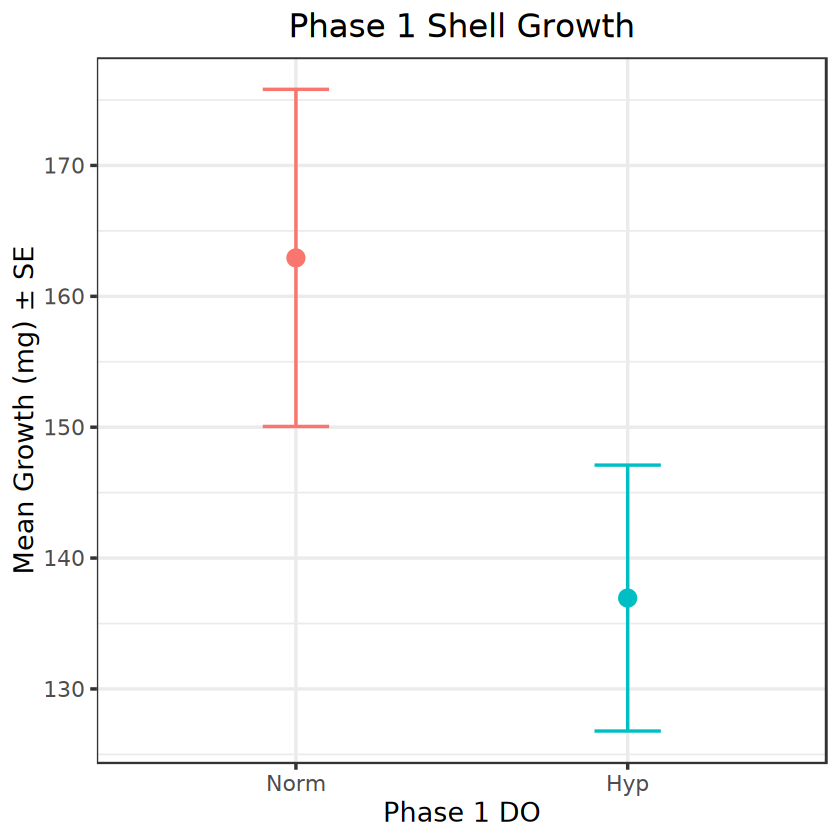

In [29]:
ggplot(DOstats, aes(x = Phase_1_DO, y = mean_growth, color = Phase_1_DO)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 DO',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Shell Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Temp only

In [30]:
# get mean and SE for phase 1 DO
tempstats <- p1.shell %>%
  group_by(Phase_1_temp) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_temp, .keep_all = TRUE)

tempstats

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_shell_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O1,Both,Hyp,Warm,42.27678,137.8647,9.619634
2024_Cont01_Null_W1,Cont,Norm,Ambient,232.44312,162.0148,13.307322


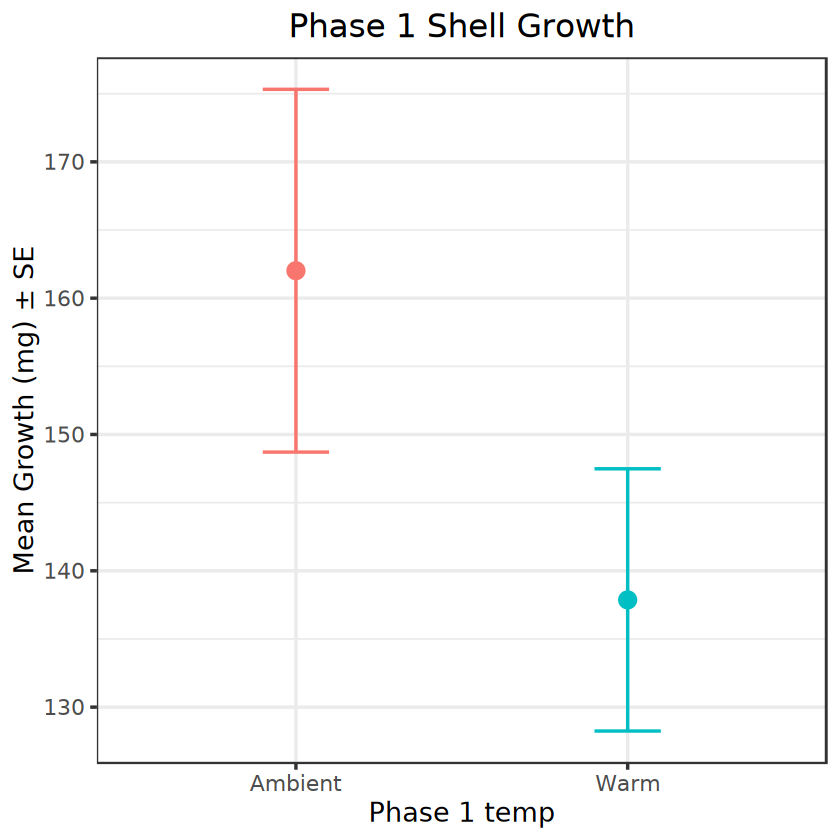

In [31]:
ggplot(tempstats, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 temp',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Shell Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Interaction

#### DO only

In [32]:
# get mean and SE for phase 1 DO
interstats <- p1.shell %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_treat, .keep_all = TRUE)

interstats

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_shell_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O1,Both,Hyp,Warm,42.27678,127.0415,14.41906
2024_Cont01_Null_W1,Cont,Norm,Ambient,232.44312,177.1825,22.38019
2024_Hyp01_Null_B1,Hyp,Hyp,Ambient,218.35086,146.8472,14.32523
2024_Warm01_Null_G1,Warm,Norm,Warm,88.19538,148.6879,12.69619


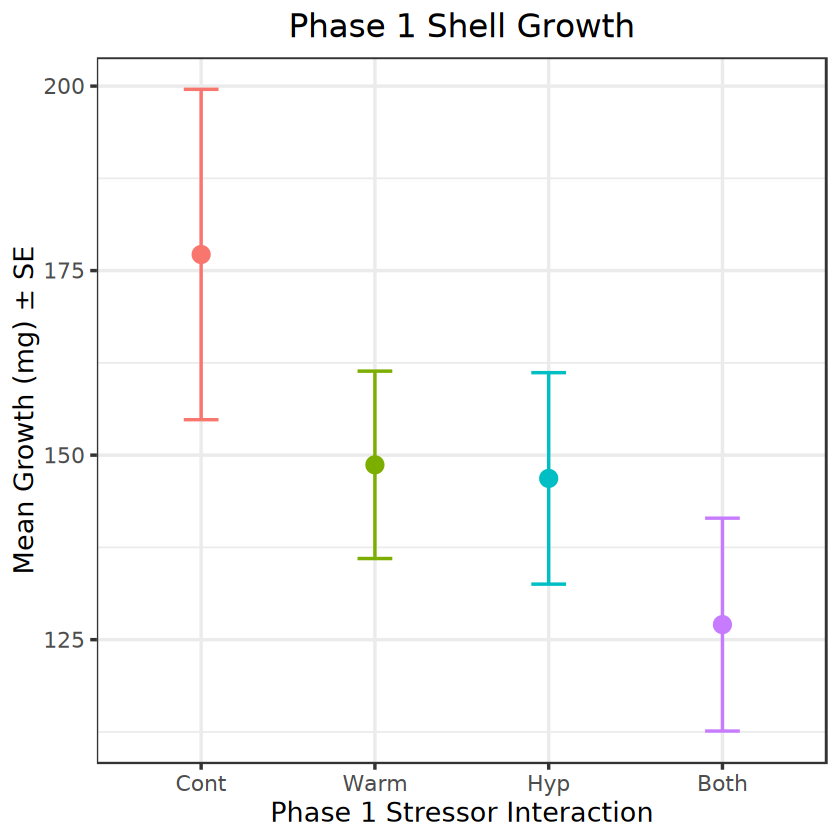

In [33]:
ggplot(interstats, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 Stressor Interaction',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Shell Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

doesn't appear to be a difference between warm and hypoxia, but a large difference between control and both

### Tissue Growth

#### DO only

In [34]:
# get mean and SE for phase 1 DO
DOstats.t <- p1.tissue %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_DO, .keep_all = TRUE)

DOstats.t

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_tissue_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O1,Both,Hyp,Warm,21.92322,96.1609,8.238814
2024_Cont01_Null_W1,Cont,Norm,Ambient,136.95688,112.4353,10.159151


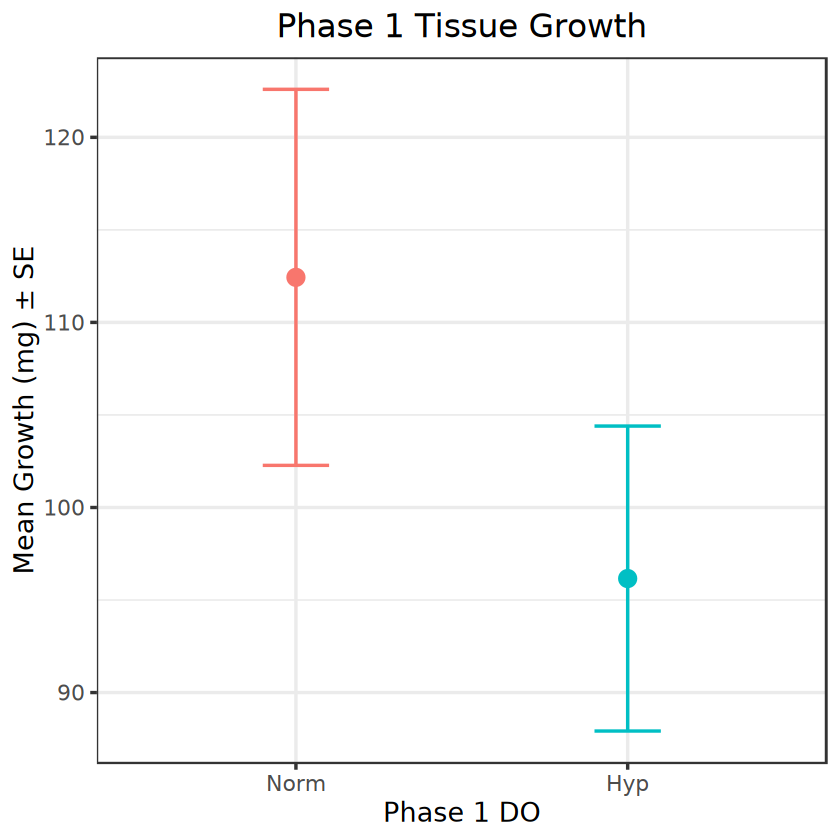

In [35]:
ggplot(DOstats.t, aes(x = Phase_1_DO, y = mean_growth, color = Phase_1_DO)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 DO',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Tissue Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Temp only

In [36]:
# get mean and SE for phase 1 DO
tempstats.t <- p1.tissue %>%
  group_by(Phase_1_temp) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_temp, .keep_all = TRUE)

tempstats.t

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_tissue_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O1,Both,Hyp,Warm,21.92322,91.1487,7.279223
2024_Cont01_Null_W1,Cont,Norm,Ambient,136.95688,117.2258,10.718182


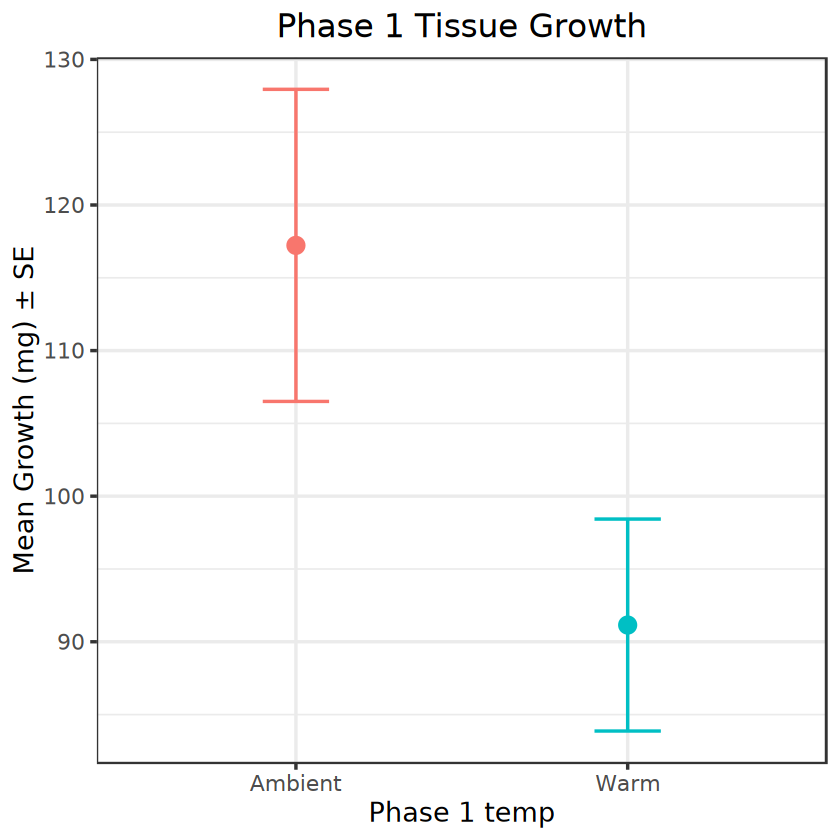

In [37]:
ggplot(tempstats.t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 temp',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Tissue Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 

#### Interaction

In [38]:
# get mean and SE for phase 1 DO
interstats.t <- p1.tissue %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE)) %>%
distinct(Phase_1_treat, .keep_all = TRUE)

interstats.t

Sample_Name,Phase_1_treat,Phase_1_DO,Phase_1_temp,Actual_tissue_growth_mg,mean_growth,se_growth
<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
2024_Both01_Null_O1,Both,Hyp,Warm,21.92322,80.85229,10.585390
2024_Cont01_Null_W1,Cont,Norm,Ambient,136.95688,122.98212,17.624374
2024_Hyp01_Null_B1,Hyp,Hyp,Ambient,172.64914,111.46951,12.344134
2024_Warm01_Null_G1,Warm,Norm,Warm,24.50462,101.66417,9.857988


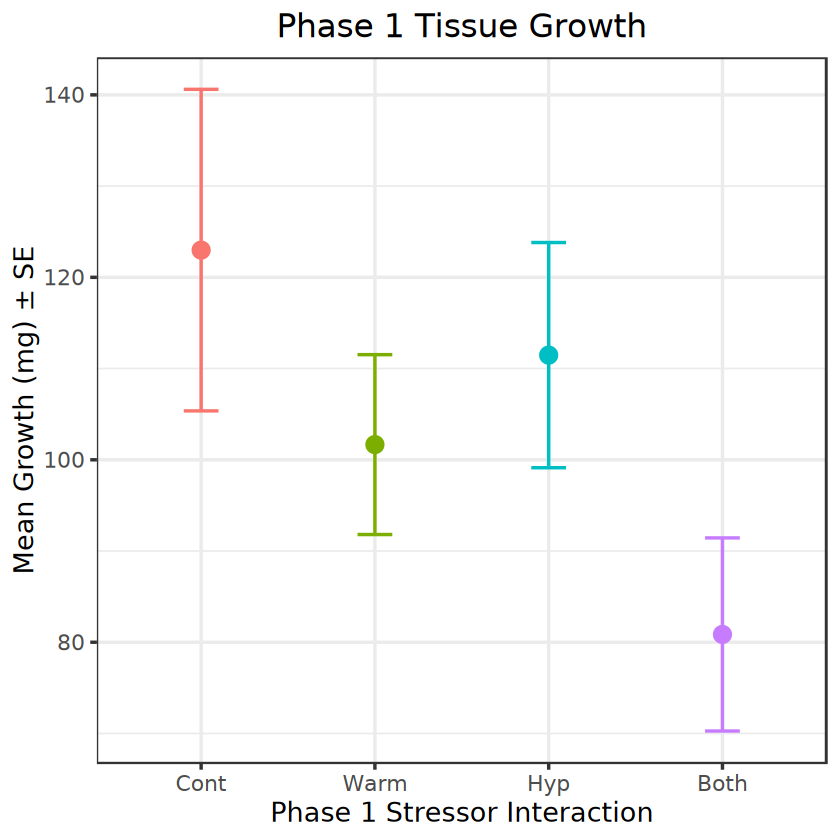

In [39]:
ggplot(interstats.t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
geom_point(size = 4, position = position_dodge(0.0)) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
              width = 0.2, position = position_dodge(0.9)) +
guides(fill = 'none') +
labs(x = 'Phase 1 Stressor Interaction',
    y = 'Mean Growth (mg) ± SE',
    title = 'Phase 1 Tissue Growth') +
theme_bw(base_size = 16) +
theme(legend.position = "none",
      plot.title = element_text(hjust = 0.5)
) 